## Liverpool Defending Champions

Looking at the how Liverpool performed in their title defense. Looking to see where the drop offs occured both attacking wise and defensively.

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
#  Cell 1 · Install & Import
# ─────────────────────────────────────────────────────────────────────────────
!pip install matplotlib numpy pandas --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from math import pi

# ── Liverpool brand palette ───────────────────────────────────────────────────
LFC_RED    = '#C8102E'
LFC_GOLD   = '#F6EB61'
LFC_GREEN  = '#00B2A9'
DARK_BG    = '#0D0D0D'
CARD_BG    = '#181818'
GRID_COL   = '#2E2E2E'
TEXT_LIGHT = '#F0F0F0'
TEXT_DIM   = '#888888'

# Season colour coding
COL_2425 = LFC_RED     # 2024/25 — champions
COL_2526 = LFC_GOLD    # 2025/26 — current

plt.rcParams.update({
    'figure.facecolor':  DARK_BG,
    'axes.facecolor':    CARD_BG,
    'axes.edgecolor':    GRID_COL,
    'axes.labelcolor':   TEXT_LIGHT,
    'xtick.color':       TEXT_LIGHT,
    'ytick.color':       TEXT_LIGHT,
    'text.color':        TEXT_LIGHT,
    'grid.color':        GRID_COL,
    'grid.linestyle':    '--',
    'grid.alpha':        0.4,
    'font.family':       'DejaVu Sans',
    'font.size':         11,
})

print('✅  Environment ready.')

✅  Environment ready.


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
#  Cell 2 · Attacking & Defensive Season Data
#
#  2024/25 sources : NBC Sports final stats, StatMuse (xG=85.25, GC=41),
#                    LFC Times (80 goals, 14 clean sheets), FotMob
#  2025/26 sources : FotMob (37 GW, May 2026), FootyStats, StatMuse (xG=56.34)
#                    Stats marked * are extrapolated to 38 games where needed.
# ─────────────────────────────────────────────────────────────────────────────

# ── Raw season totals ─────────────────────────────────────────────────────────
# Columns: Goals, xG, Shots on Target (total), Big Chances Created,
#          Assists, Key Passes (est), Goals Conceded, xGA (total),
#          Clean Sheets, Tackles Won (est), Interceptions (est)

raw = pd.DataFrame({
    'Metric'           : ['Goals', 'xG', 'Shots on Target', 'Big Chances',
                          'Assists', 'Goals Conceded', 'xGA',
                          'Clean Sheets', 'Tackles Won', 'Interceptions'],
    '2024/25 (38gm)'   : [80,  85.3, 211, 63,  66,  41, 44.2, 14, 420, 490],
    '2025/26 (≈38gm)'  : [62,  58.1, 167, 47,  51,  52, 50.2,  5, 385, 450],
})
# 2025/26 totals scaled from ~37 GW to 38 (multiply by 38/37)
scale = 38 / 37
for col in ['Goals','xG','Shots on Target','Big Chances',
            'Assists','Goals Conceded','xGA','Tackles Won','Interceptions']:
    raw.loc[raw['Metric'] == col, '2025/26 (≈38gm)'] = (
        raw.loc[raw['Metric'] == col, '2025/26 (≈38gm)'].values[0] * scale
    ).round(1)

raw.set_index('Metric', inplace=True)
print(raw.to_string())

                 2024/25 (38gm)  2025/26 (≈38gm)
Metric                                          
Goals                      80.0             63.7
xG                         85.3             59.7
Shots on Target           211.0            171.5
Big Chances                63.0             48.3
Assists                    66.0             52.4
Goals Conceded             41.0             53.4
xGA                        44.2             51.6
Clean Sheets               14.0              5.0
Tackles Won               420.0            395.4
Interceptions             490.0            462.2


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
#  Cell 3 · Normalised radar scores (0–10)
#  Each metric is normalised relative to a realistic PL top-half min/max range.
# ─────────────────────────────────────────────────────────────────────────────

# Reference ranges [worst-typical, best-typical] for PL top clubs over 38 games
ref_ranges = {
    # ATTACKING
    'Goals'           : (45, 95),
    'xG'              : (40, 90),
    'Shots on Target' : (120, 230),
    'Big Chances'     : (30, 75),
    'Assists'         : (35, 75),
    # DEFENSIVE  (for Goals Conceded & xGA: lower = better, so we invert)
    'Goals Conceded'  : (25, 65),   # inverted below
    'xGA'             : (28, 70),   # inverted below
    'Clean Sheets'    : (5, 20),
    'Tackles Won'     : (300, 500),
    'Interceptions'   : (350, 570),
}

def normalise(value, lo, hi, invert=False):
    score = 10 * (value - lo) / (hi - lo)
    score = max(0, min(10, score))
    return round(10 - score if invert else score, 2)

attack_labels  = ['Goals', 'xG', 'Shots on Target', 'Big Chances', 'Assists']
defence_labels = ['Clean Sheets', 'Goals Conceded', 'xGA', 'Tackles Won', 'Interceptions']

invert_set = {'Goals Conceded', 'xGA'}

def get_scores(season_col, label_list):
    scores = []
    for m in label_list:
        val = raw.loc[m, season_col]
        lo, hi = ref_ranges[m]
        inv = m in invert_set
        scores.append(normalise(val, lo, hi, invert=inv))
    return scores

atk_2425  = get_scores('2024/25 (38gm)',  attack_labels)
atk_2526  = get_scores('2025/26 (≈38gm)', attack_labels)
def_2425  = get_scores('2024/25 (38gm)',  defence_labels)
def_2526  = get_scores('2025/26 (≈38gm)', defence_labels)

print('Attack  scores 24/25:', atk_2425)
print('Attack  scores 25/26:', atk_2526)
print('Defence scores 24/25:', def_2425)
print('Defence scores 25/26:', def_2526)

Attack  scores 24/25: [np.float64(7.0), np.float64(9.06), np.float64(8.27), np.float64(7.33), np.float64(7.75)]
Attack  scores 25/26: [np.float64(3.74), np.float64(3.94), np.float64(4.68), np.float64(4.07), np.float64(4.35)]
Defence scores 24/25: [np.float64(6.0), np.float64(6.0), np.float64(6.14), np.float64(6.0), np.float64(6.36)]
Defence scores 25/26: [0, np.float64(2.9), np.float64(4.38), np.float64(4.77), np.float64(5.1)]


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
#  Cell 4 · Goal-scorer data
#
#  2024/25 PL goals: NBC Sports final table (Salah 29, Gakpo 10, Diaz 13,
#          Jota 6, Szoboszlai 6, Mac Allister 5, Nunez 5, van Dijk 3,
#          Elliott 4 [all comps 5], Alexander-Arnold 3, Jones 3,
#          Konate 1, OG 3)
#  2025/26: FootyStats May 2026 (Ekitike 11, Salah 7, Gakpo 7, van Dijk 6,
#           Szoboszlai 6, Wirtz 5, Gravenberch 5, others)
# ─────────────────────────────────────────────────────────────────────────────

scorers_2425 = pd.DataFrame([
    {'Player': 'M. Salah',           'Position': 'Forward',    'Goals': 29},
    {'Player': 'L. Díaz',            'Position': 'Forward',    'Goals': 13},
    {'Player': 'C. Gakpo',           'Position': 'Forward',    'Goals': 10},
    {'Player': 'D. Jota',            'Position': 'Forward',    'Goals':  6},
    {'Player': 'D. Szoboszlai',      'Position': 'Midfielder', 'Goals':  6},
    {'Player': 'A. Mac Allister',    'Position': 'Midfielder', 'Goals':  5},
    {'Player': 'D. Núñez',           'Position': 'Forward',    'Goals':  5},
    {'Player': 'H. Elliott',         'Position': 'Midfielder', 'Goals':  4},
    {'Player': 'T. Alexander-Arnold','Position': 'Defender',   'Goals':  3},
    {'Player': 'V. van Dijk',        'Position': 'Defender',   'Goals':  3},
    {'Player': 'C. Jones',           'Position': 'Midfielder', 'Goals':  3},
    {'Player': 'I. Konaté',          'Position': 'Defender',   'Goals':  1},
    {'Player': 'Own Goals',          'Position': 'Other',      'Goals':  3},
]).sort_values('Goals', ascending=False).reset_index(drop=True)

scorers_2526 = pd.DataFrame([
    {'Player': 'H. Ekitike',         'Position': 'Forward',    'Goals': 11},
    {'Player': 'M. Salah',           'Position': 'Forward',    'Goals':  7},
    {'Player': 'C. Gakpo',           'Position': 'Forward',    'Goals':  7},
    {'Player': 'V. van Dijk',        'Position': 'Defender',   'Goals':  6},
    {'Player': 'D. Szoboszlai',      'Position': 'Midfielder', 'Goals':  6},
    {'Player': 'F. Wirtz',           'Position': 'Midfielder', 'Goals':  5},
    {'Player': 'R. Gravenberch',     'Position': 'Midfielder', 'Goals':  5},
    {'Player': 'A. Mac Allister',    'Position': 'Midfielder', 'Goals':  4},
    {'Player': 'L. Díaz',            'Position': 'Forward',    'Goals':  3},
    {'Player': 'D. Jota',            'Position': 'Forward',    'Goals':  3},
    {'Player': 'I. Konaté',          'Position': 'Defender',   'Goals':  2},
    {'Player': 'C. Jones',           'Position': 'Midfielder', 'Goals':  2},
    {'Player': 'Own Goals',          'Position': 'Other',      'Goals':  3},
]).sort_values('Goals', ascending=False).reset_index(drop=True)

print(f"2024/25 total goals: {scorers_2425['Goals'].sum()}")
print(f"2025/26 total goals: {scorers_2526['Goals'].sum()} (tracked scorers)")

2024/25 total goals: 91
2025/26 total goals: 64 (tracked scorers)


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
#  Cell 5 · Radar helper
# ─────────────────────────────────────────────────────────────────────────────

def draw_radar(ax, categories, values_a, values_b,
               label_a='2024/25', label_b='2025/26',
               color_a=COL_2425, color_b=COL_2526,
               vmin=0, vmax=10, title=''):
    """Draw a dual radar chart on a pre-existing polar Axes."""
    N = len(categories)
    angles = [n / N * 2 * pi for n in range(N)]
    angles += angles[:1]

    va = list(values_a) + [values_a[0]]
    vb = list(values_b) + [values_b[0]]

    ax.set_facecolor(CARD_BG)
    ax.set_ylim(vmin, vmax)

    # Ring labels
    tick_vals = np.arange(2, vmax + 1, 2)
    ax.set_yticks(tick_vals)
    ax.set_yticklabels([str(int(v)) for v in tick_vals], color=TEXT_DIM, fontsize=7)
    ax.set_rlabel_position(20)

    # Spoke labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, color=TEXT_LIGHT, fontsize=8.5, fontweight='bold')
    ax.tick_params(axis='x', pad=12)

    # Styling
    ax.spines['polar'].set_color(GRID_COL)
    ax.grid(color=GRID_COL, linestyle='--', linewidth=0.6, alpha=0.5)

    # Season A — champions
    ax.plot(angles, va, color=color_a, linewidth=2.4, linestyle='solid', zorder=3)
    ax.fill(angles, va, color=color_a, alpha=0.22, zorder=2)
    ax.scatter(angles[:-1], values_a, color=color_a, s=45, zorder=5)

    # Season B — current
    ax.plot(angles, vb, color=color_b, linewidth=2.4, linestyle='solid', zorder=3)
    ax.fill(angles, vb, color=color_b, alpha=0.22, zorder=2)
    ax.scatter(angles[:-1], values_b, color=color_b, s=45, zorder=5)

    if title:
        ax.set_title(title, fontsize=13, fontweight='bold',
                     color=TEXT_LIGHT, pad=20)

    return ax

print('✅  Radar helper ready.')

✅  Radar helper ready.


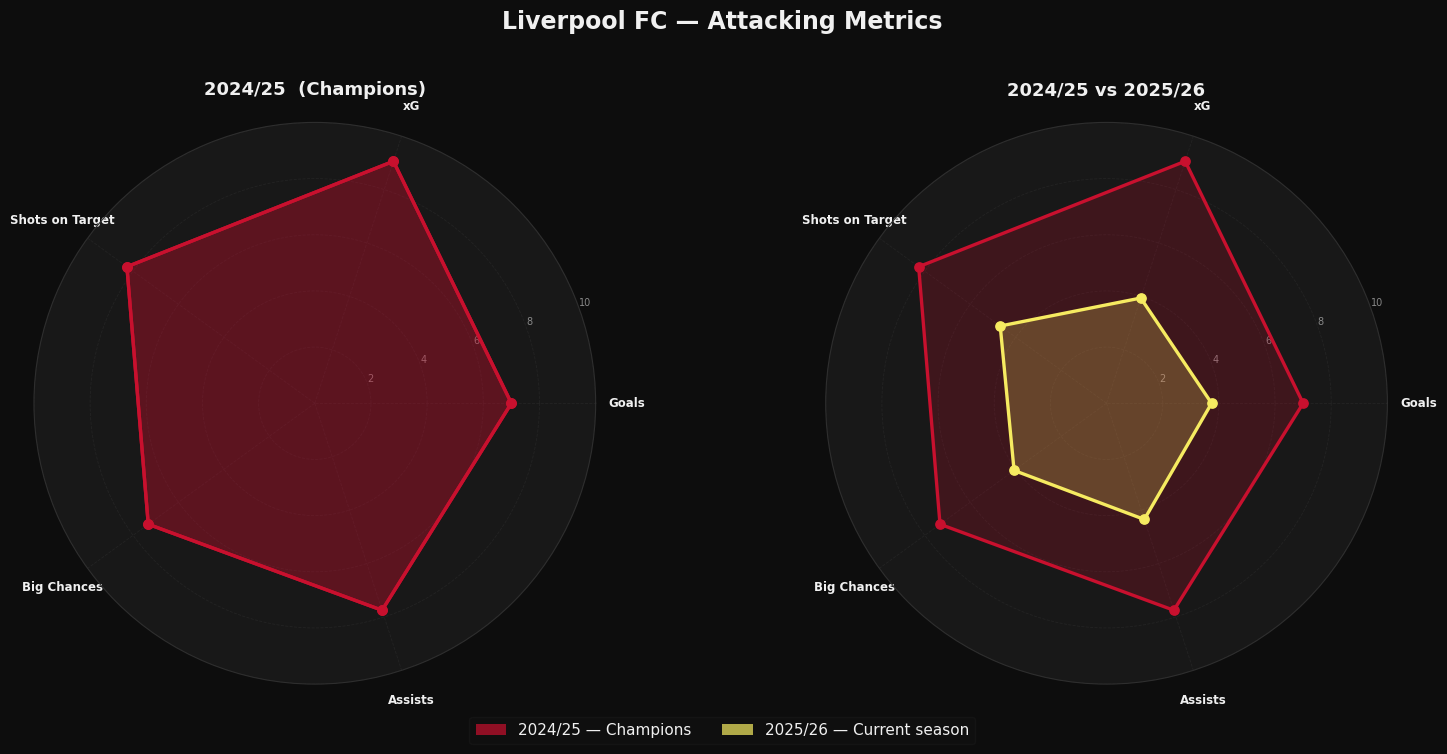

✅  Attacking radar saved.


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
#  Cell 6 · Attacking radar
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 7),
                         subplot_kw=dict(polar=True),
                         facecolor=DARK_BG)
fig.suptitle('Liverpool FC — Attacking Metrics',
             fontsize=17, fontweight='bold', color=TEXT_LIGHT, y=1.02)

# Left — 2024/25 solo
draw_radar(axes[0], attack_labels,
           atk_2425, atk_2425,   # same season fills both layers → solid shape
           color_a=COL_2425, color_b=COL_2425,
           title='2024/25  (Champions)')

# Right — overlay comparison
draw_radar(axes[1], attack_labels,
           atk_2425, atk_2526,
           color_a=COL_2425, color_b=COL_2526,
           title='2024/25 vs 2025/26')

# Shared legend
patch_a = mpatches.Patch(facecolor=COL_2425, alpha=0.7, label='2024/25 — Champions')
patch_b = mpatches.Patch(facecolor=COL_2526, alpha=0.7, label='2025/26 — Current season')
fig.legend(handles=[patch_a, patch_b],
           loc='lower center', ncol=2,
           fontsize=11, framealpha=0.2,
           facecolor=CARD_BG, edgecolor=GRID_COL,
           labelcolor=TEXT_LIGHT, bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
plt.savefig('liverpool_attack_radar.png', dpi=150, bbox_inches='tight',
            facecolor=DARK_BG)
plt.show()
print('✅  Attacking radar saved.')

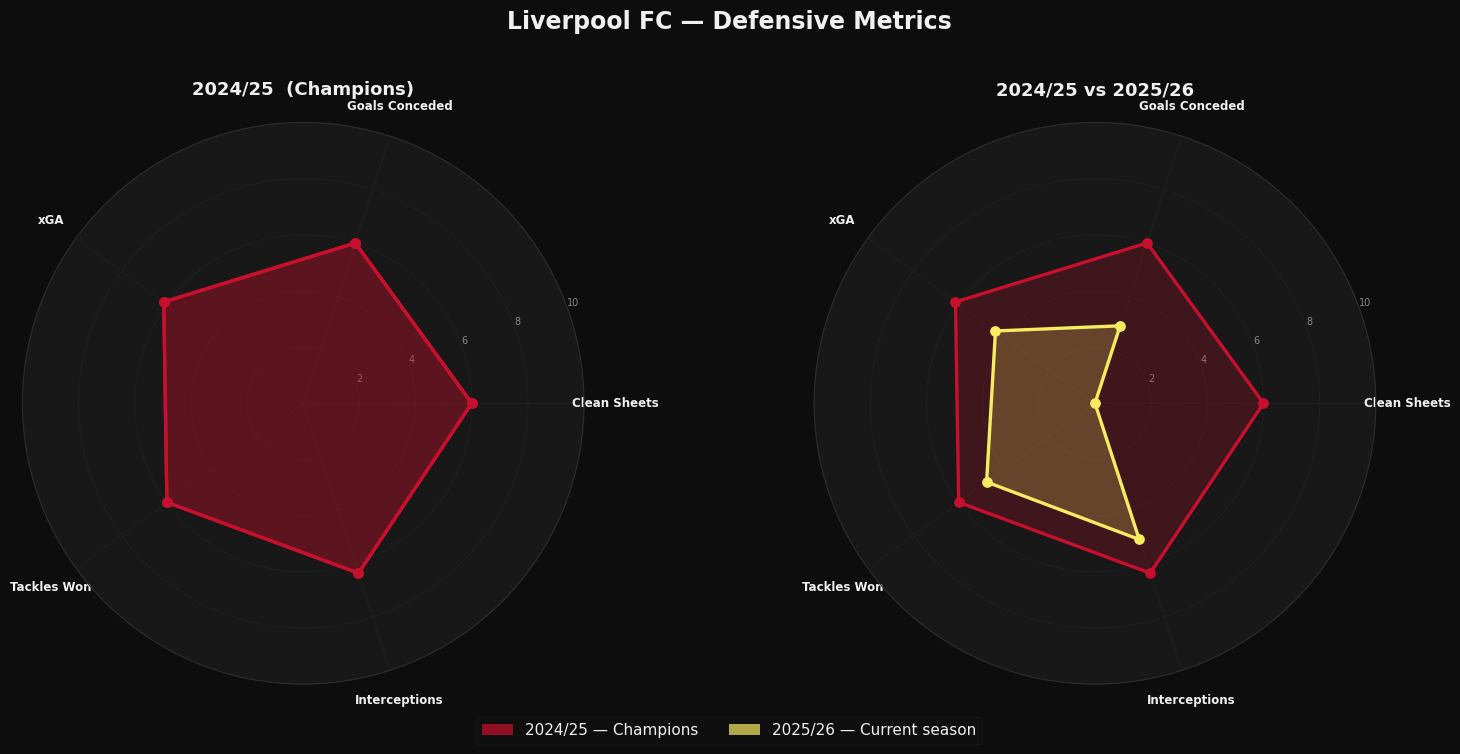

✅  Defensive radar saved.


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
#  Cell 7 · Defensive radar
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 7),
                         subplot_kw=dict(polar=True),
                         facecolor=DARK_BG)
fig.suptitle('Liverpool FC — Defensive Metrics',
             fontsize=17, fontweight='bold', color=TEXT_LIGHT, y=1.02)

# Left — 2024/25 solo
draw_radar(axes[0], defence_labels,
           def_2425, def_2425,
           color_a=COL_2425, color_b=COL_2425,
           title='2024/25  (Champions)')

# Right — overlay comparison
draw_radar(axes[1], defence_labels,
           def_2425, def_2526,
           color_a=COL_2425, color_b=COL_2526,
           title='2024/25 vs 2025/26')

# Shared legend
patch_a = mpatches.Patch(facecolor=COL_2425, alpha=0.7, label='2024/25 — Champions')
patch_b = mpatches.Patch(facecolor=COL_2526, alpha=0.7, label='2025/26 — Current season')
fig.legend(handles=[patch_a, patch_b],
           loc='lower center', ncol=2,
           fontsize=11, framealpha=0.2,
           facecolor=CARD_BG, edgecolor=GRID_COL,
           labelcolor=TEXT_LIGHT, bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
plt.savefig('liverpool_defence_radar.png', dpi=150, bbox_inches='tight',
            facecolor=DARK_BG)
plt.show()
print('✅  Defensive radar saved.')

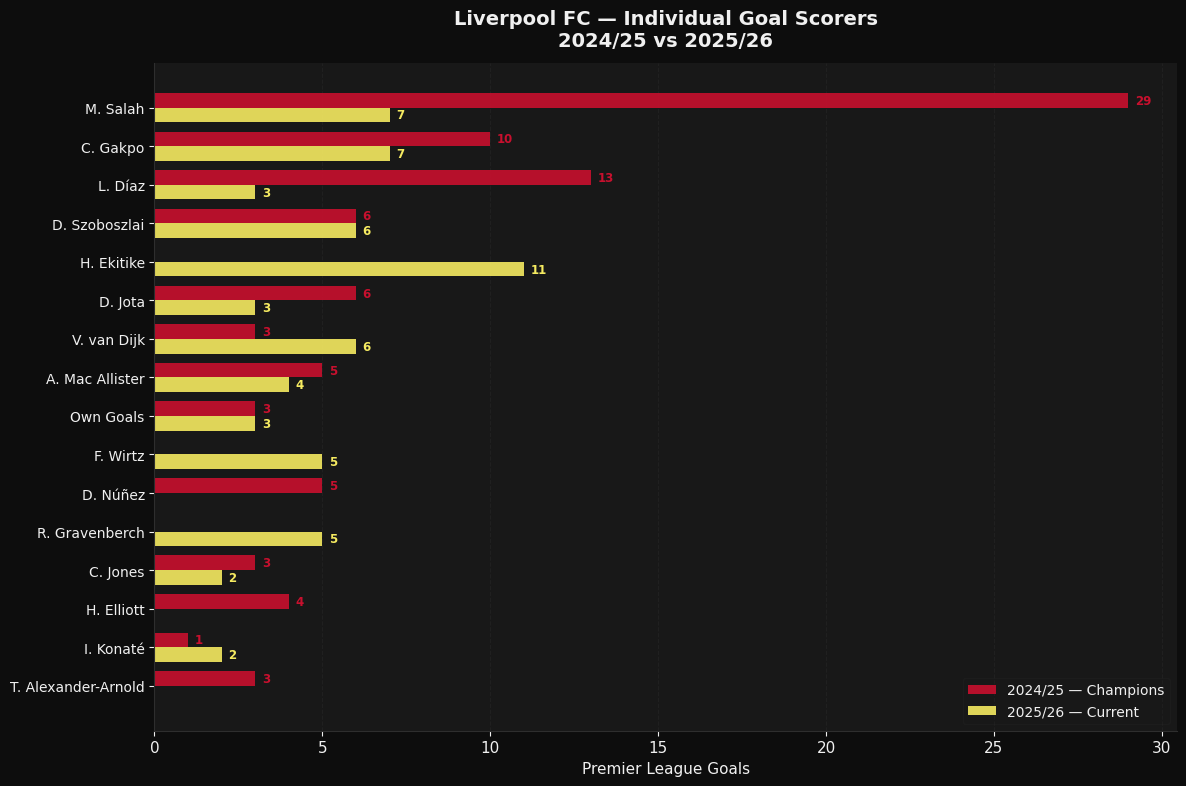

✅  Individual goal chart saved.


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
#  Cell 8 · Individual goal distribution — grouped bar chart
# ─────────────────────────────────────────────────────────────────────────────

# Build a unified player list across both seasons
all_players = pd.concat([scorers_2425[['Player','Goals']].rename(columns={'Goals':'2024/25'}),
                         scorers_2526[['Player','Goals']].rename(columns={'Goals':'2025/26'})],
                        ignore_index=True)

all_players = (
    scorers_2425[['Player','Goals']].rename(columns={'Goals':'2024/25'})
    .merge(scorers_2526[['Player','Goals']].rename(columns={'Goals':'2025/26'}),
           on='Player', how='outer')
    .fillna(0)
)
all_players['2024/25'] = all_players['2024/25'].astype(int)
all_players['2025/26'] = all_players['2025/26'].astype(int)

# Sort by combined goals
all_players['Total'] = all_players['2024/25'] + all_players['2025/26']
all_players = all_players.sort_values('Total', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 8), facecolor=DARK_BG)
ax.set_facecolor(CARD_BG)

y = np.arange(len(all_players))
h = 0.38

bars_a = ax.barh(y + h/2, all_players['2024/25'], height=h,
                 color=COL_2425, alpha=0.9, label='2024/25 — Champions')
bars_b = ax.barh(y - h/2, all_players['2025/26'], height=h,
                 color=COL_2526, alpha=0.9, label='2025/26 — Current')

# Value labels
for bar in bars_a:
    w = bar.get_width()
    if w > 0:
        ax.text(w + 0.2, bar.get_y() + bar.get_height()/2,
                str(int(w)), va='center', ha='left',
                color=COL_2425, fontsize=8.5, fontweight='bold')
for bar in bars_b:
    w = bar.get_width()
    if w > 0:
        ax.text(w + 0.2, bar.get_y() + bar.get_height()/2,
                str(int(w)), va='center', ha='left',
                color=COL_2526, fontsize=8.5, fontweight='bold')

ax.set_yticks(y)
ax.set_yticklabels(all_players['Player'], fontsize=10)
ax.set_xlabel('Premier League Goals', fontsize=11, color=TEXT_LIGHT)
ax.set_title('Liverpool FC — Individual Goal Scorers\n2024/25 vs 2025/26',
             fontsize=14, fontweight='bold', color=TEXT_LIGHT, pad=12)
ax.legend(fontsize=10, framealpha=0.2, facecolor=CARD_BG,
          edgecolor=GRID_COL, labelcolor=TEXT_LIGHT)
ax.spines[['top','right']].set_visible(False)
ax.spines[['left','bottom']].set_color(GRID_COL)
ax.tick_params(colors=TEXT_LIGHT)
ax.xaxis.grid(True, color=GRID_COL, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('liverpool_individual_goals.png', dpi=150,
            bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print('✅  Individual goal chart saved.')

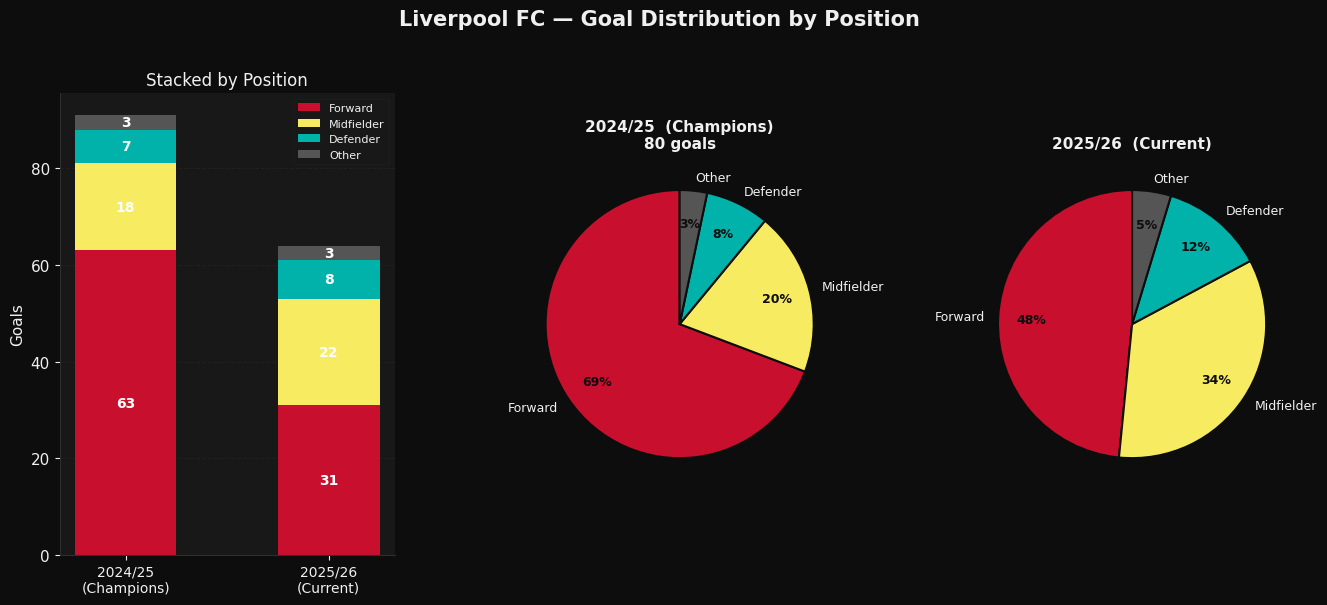

✅  Positional goal chart saved.


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
#  Cell 9 · Positional goal distribution — stacked bar + twin pie charts
# ─────────────────────────────────────────────────────────────────────────────

pos_order   = ['Forward', 'Midfielder', 'Defender', 'Other']
pos_colours = {
    'Forward'   : '#C8102E',   # LFC red
    'Midfielder': '#F6EB61',   # LFC gold
    'Defender'  : '#00B2A9',   # LFC teal
    'Other'     : '#555555',   # grey (own goals etc.)
}

def pos_totals(df):
    return df.groupby('Position')['Goals'].sum().reindex(pos_order, fill_value=0)

pos_2425 = pos_totals(scorers_2425)
pos_2526 = pos_totals(scorers_2526)

# ── Figure layout: 1 stacked bar (left) + 2 pies (right) ─────────────────────
fig = plt.figure(figsize=(16, 6), facecolor=DARK_BG)
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

ax_bar  = fig.add_subplot(gs[0, 0])
ax_pie1 = fig.add_subplot(gs[0, 1])
ax_pie2 = fig.add_subplot(gs[0, 2])

fig.suptitle('Liverpool FC — Goal Distribution by Position',
             fontsize=15, fontweight='bold', color=TEXT_LIGHT, y=1.02)

# ── Stacked bar ───────────────────────────────────────────────────────────────
ax_bar.set_facecolor(CARD_BG)
seasons_labels = ['2024/25\n(Champions)', '2025/26\n(Current)']
bottom_a = bottom_b = 0
handles  = []

for pos in pos_order:
    g_a = pos_2425[pos]
    g_b = pos_2526[pos]
    c   = pos_colours[pos]
    b_a = ax_bar.bar(0, g_a, bottom=bottom_a, color=c, width=0.5, label=pos)
    b_b = ax_bar.bar(1, g_b, bottom=bottom_b, color=c, width=0.5)
    # Segment labels
    if g_a > 0:
        ax_bar.text(0, bottom_a + g_a/2, str(g_a), ha='center', va='center',
                    color='white', fontsize=10, fontweight='bold')
    if g_b > 0:
        ax_bar.text(1, bottom_b + g_b/2, str(g_b), ha='center', va='center',
                    color='white', fontsize=10, fontweight='bold')
    handles.append(mpatches.Patch(facecolor=c, label=pos))
    bottom_a += g_a
    bottom_b += g_b

ax_bar.set_xticks([0, 1])
ax_bar.set_xticklabels(seasons_labels, color=TEXT_LIGHT, fontsize=10)
ax_bar.set_ylabel('Goals', color=TEXT_LIGHT)
ax_bar.set_title('Stacked by Position', color=TEXT_LIGHT, fontsize=12)
ax_bar.spines[['top','right']].set_visible(False)
ax_bar.spines[['left','bottom']].set_color(GRID_COL)
ax_bar.tick_params(colors=TEXT_LIGHT)
ax_bar.yaxis.grid(True, color=GRID_COL, linestyle='--', alpha=0.4)
ax_bar.set_axisbelow(True)
ax_bar.legend(handles=handles, loc='upper right', fontsize=8,
              framealpha=0.2, facecolor=CARD_BG, edgecolor=GRID_COL,
              labelcolor=TEXT_LIGHT)

# ── Pie 2024/25 ───────────────────────────────────────────────────────────────
ax_pie1.set_facecolor(DARK_BG)
colours_ordered = [pos_colours[p] for p in pos_order]
wedges1, texts1, auto1 = ax_pie1.pie(
    pos_2425.values,
    labels=pos_order,
    colors=colours_ordered,
    autopct='%1.0f%%',
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(linewidth=1.5, edgecolor=DARK_BG),
    textprops=dict(color=TEXT_LIGHT, fontsize=9)
)
for at in auto1:
    at.set_fontsize(9)
    at.set_color(DARK_BG)
    at.set_fontweight('bold')
ax_pie1.set_title('2024/25  (Champions)\n80 goals',
                  color=TEXT_LIGHT, fontsize=11, fontweight='bold')

# ── Pie 2025/26 ───────────────────────────────────────────────────────────────
ax_pie2.set_facecolor(DARK_BG)
wedges2, texts2, auto2 = ax_pie2.pie(
    pos_2526.values,
    labels=pos_order,
    colors=colours_ordered,
    autopct='%1.0f%%',
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(linewidth=1.5, edgecolor=DARK_BG),
    textprops=dict(color=TEXT_LIGHT, fontsize=9)
)
for at in auto2:
    at.set_fontsize(9)
    at.set_color(DARK_BG)
    at.set_fontweight('bold')
ax_pie2.set_title('2025/26  (Current)',
                  color=TEXT_LIGHT, fontsize=11, fontweight='bold')

plt.savefig('liverpool_position_goals.png', dpi=150,
            bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print('✅  Positional goal chart saved.')

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
#  Cell 10 · Printed summary comparison table
# ─────────────────────────────────────────────────────────────────────────────

summary = pd.DataFrame({
    'Metric'                  : ['League Position', 'Points', 'W–D–L',
                                  'Goals Scored', 'Goals Conceded',
                                  'Goal Difference', 'xG', 'xGA',
                                  'Clean Sheets', 'Top Scorer (PL)'],
    '2024/25 (Final)'         : ['1st 🏆', '88', '25–13–0',
                                  '80', '41', '+39',
                                  '85.3', '44.2', '14',
                                  'Salah 29'],
    '2025/26 (≈37 GW)'        : ['5th', '59', '17–8–12',
                                  '62', '52', '+10',
                                  '56.3', '48.8', '5',
                                  'Ekitike 11'],
})

try:
    from IPython.display import display
    display(summary.set_index('Metric').style
            .set_properties(**{'background-color': '#181818',
                               'color': '#F0F0F0',
                               'border-color': '#2E2E2E'})
            .set_table_styles([{
                'selector': 'th',
                'props': [('background-color', '#C8102E'),
                          ('color', 'white'),
                          ('font-weight', 'bold')]
            }]))
except ImportError:
    print(summary.to_string(index=False))

,2024/25 (Final),2025/26 (≈37 GW)
Metric,,
League Position,1st 🏆,5th
Points,88,59
W–D–L,25–13–0,17–8–12
Goals Scored,80,62
Goals Conceded,41,52
Goal Difference,+39,+10
xG,85.3,56.3
xGA,44.2,48.8
Clean Sheets,14,5
